#Human Activity Pattern Discovery Using Smartphone Sensor Data: A Comparative Clustering Analysis

**Features:**

* 561 sensor features
* Walking
* Sitting
* Standing
* Laying

**Algorithms:**

* K-Means
* Hierarchy
* DBScan
* GMM (Gaussian Mixture Model)

**Dataset size**

**The HAR dataset contains:**

10,299 samples
561 numerical features

This is much smaller than your 100,000-row Health & Lifestyle dataset, so most clustering algorithms will run faster.

**Import Libraries**

In [239]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    OPTICS,
    SpectralClustering,
    Birch
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import matplotlib.pyplot as plt
import seaborn as sns

#Upload Dataset

In [240]:
#from google.colab import files

#uploaded = files.upload()

In [241]:
import pandas as pd

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

#Load Dataset

In [242]:
import pandas as pd
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (7352, 563)
Test Shape: (2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


#Merge Dataset

In [243]:
df = pd.concat([train, test], ignore_index=True)

print("Combined Shape:", df.shape)

df.head()

Combined Shape: (10299, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


#Prepare Features

In [244]:
X = df.drop(['subject','Activity'], axis=1)
y = df['Activity']

print(X.shape)
print(y.shape)

(10299, 561)
(10299,)


In [245]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


#Feature Scaling

In [246]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(10299, 561)


#PCA

In [247]:
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=20)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

print(
    "Explained Variance:",
    round(np.sum(pca.explained_variance_ratio_)*100,2),
    "%"
)

(10299, 20)
Explained Variance: 76.84 %


Setting **n_components=0.95** means you want PCA to select the minimum number of components needed to retain 95% of the variance (information) from your original dataset.Instead of choosing a fixed number of features (like 2 or 3), you are telling the algorithm to preserve 95% of the data's total spread and discard the 5% that represents minor noise.

In [248]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original Features:", X.shape[1])
print("PCA Features:", X_pca.shape[1])

Original Features: 561
PCA Features: 104


These lines are used to inspect the dataset before applying machine learning algorithms.

print(train.columns[:20])
train.columns → returns all column names in the training dataset.
[:20] → selects the first 20 column names.
print() → displays them.

In [249]:
print(train.columns[:20])
print(train.shape)
print(test.shape)

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z',
       'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z',
       'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y',
       'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X'],
      dtype='object')
(7352, 563)
(2947, 563)


In [250]:
print(train.columns[-10:])

Index(['fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object')


#Create Result Dictionary

In [251]:
results = {}

## Data Quality Assessment

This step evaluates the quality of the dataset by examining its structure, identifying missing values, and detecting duplicate records. Ensuring data quality is essential before performing clustering, as missing or duplicate data can affect the accuracy and reliability of the clustering results.

**Tasks Performed:**
- Display dataset information and data types.
- Check for missing values.
- Identify duplicate rows.
- Verify dataset readiness for clustering analysis.

In [252]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 44.2+ MB
None

Missing Values:
0

Duplicate Rows:
0


## Activity Distribution

A count plot is used to visualize the number of records for each activity in the dataset. This helps in understanding the data distribution and identifying any class imbalance.

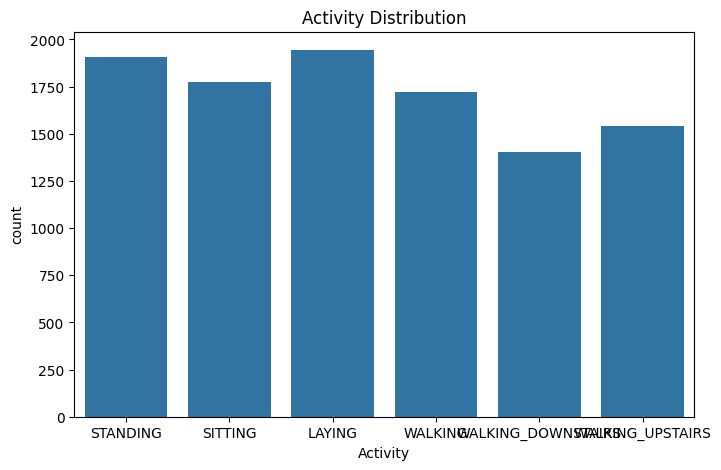

Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [253]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='Activity',
    data=df
)

plt.title("Activity Distribution")

plt.show()

print(df['Activity'].value_counts())

In [254]:
X = df.drop(
    columns=[
        'Activity',
        'subject'
    ]
)

y = df['Activity']

print(X.shape)

(10299, 561)


## PCA Cumulative Variance Analysis

This step applies Principal Component Analysis (PCA) to the standardized dataset and visualizes the cumulative explained variance. The plot helps determine the number of principal components required to retain 95% of the dataset information for dimensionality reduction.

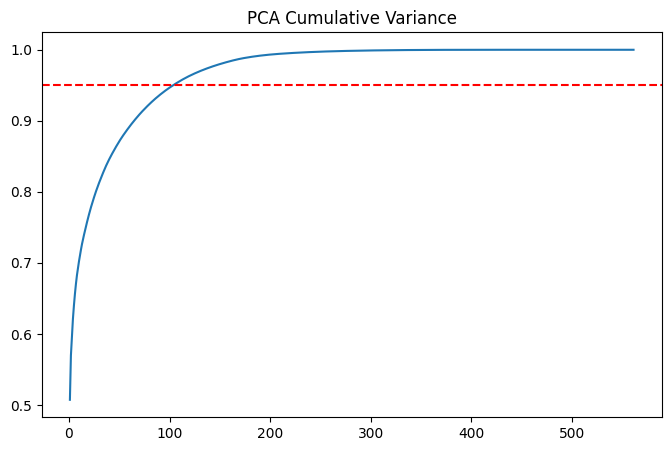

In [255]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()

pca.fit(X_scaled)

cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var
)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--'
)

plt.title(
    "PCA Cumulative Variance"
)

plt.show()

In [256]:
pca = PCA(
    n_components=0.95
)

X_pca = pca.fit_transform(
    X_scaled
)

print(
    "Original:",
    X_scaled.shape
)

print(
    "PCA:",
    X_pca.shape
)

Original: (10299, 561)
PCA: (10299, 104)


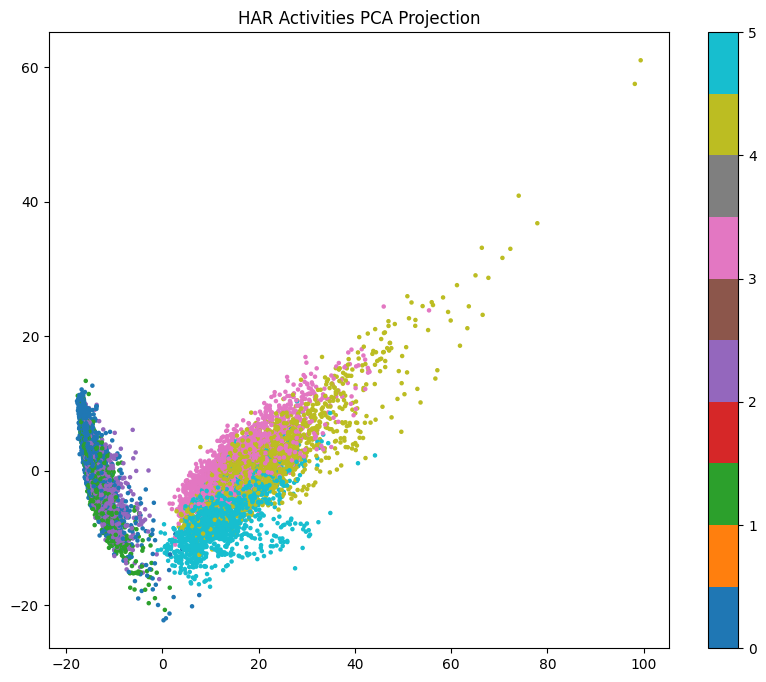

In [257]:
pca2 = PCA(
    n_components=2
)

X_vis = pca2.fit_transform(
    X_scaled
)

plt.figure(figsize=(10,8))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y_encoded,
    cmap='tab10',
    s=5
)

plt.colorbar()

plt.title(
    "HAR Activities PCA Projection"
)

plt.show()

## Feature Importance

Random Forest is used to rank features based on their importance. The top 20 most significant features are displayed for further analysis.

In [258]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X,y)

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(
    importance.head(20)
)

                             Feature  Importance
40              tGravityAcc-mean()-X    0.037120
49               tGravityAcc-max()-X    0.032881
558             angle(X,gravityMean)    0.031846
56            tGravityAcc-energy()-X    0.027499
41              tGravityAcc-mean()-Y    0.024777
52               tGravityAcc-min()-X    0.020739
50               tGravityAcc-max()-Y    0.020083
559             angle(Y,gravityMean)    0.019457
53               tGravityAcc-min()-Y    0.018596
57            tGravityAcc-energy()-Y    0.012215
83              tBodyAccJerk-std()-X    0.012148
560             angle(Z,gravityMean)    0.011463
389  fBodyAccJerk-bandsEnergy()-1,16    0.011286
3                   tBodyAcc-std()-X    0.011199
201                tBodyAccMag-std()    0.010903
74         tGravityAcc-arCoeff()-Z,2    0.010394
393  fBodyAccJerk-bandsEnergy()-1,24    0.010292
181            tBodyGyroJerk-iqr()-Z    0.010216
69         tGravityAcc-arCoeff()-Y,1    0.009196
508             fBod

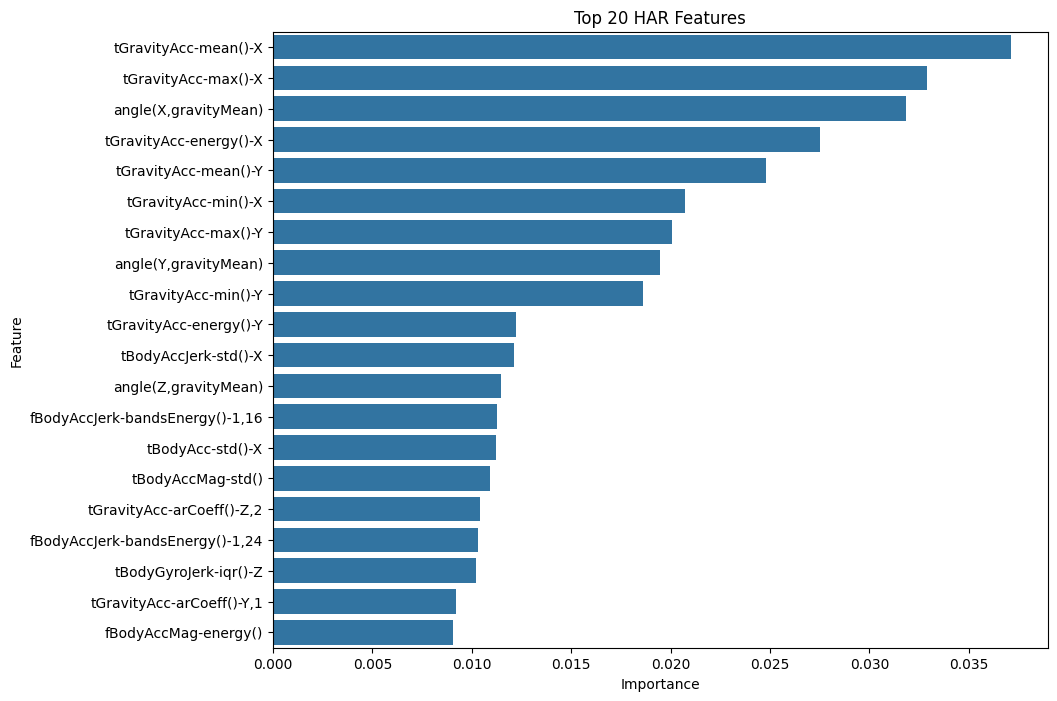

In [259]:
plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(20)
)

plt.title(
    "Top 20 HAR Features"
)

plt.show()

In [260]:
top_features = (
    importance
    .head(50)
    ['Feature']
    .tolist()
)

X_selected = X[top_features]

print(
    X_selected.shape
)

(10299, 50)


## Elbow Method

The Elbow Method is used to determine the optimal number of clusters (K) for K-Means clustering. It analyzes the Within-Cluster Sum of Squares (WCSS) for different values of K and identifies the point where the decrease in WCSS begins to slow down, forming an "elbow" shape.

**Purpose:** To select the most appropriate number of clusters for clustering analysis.

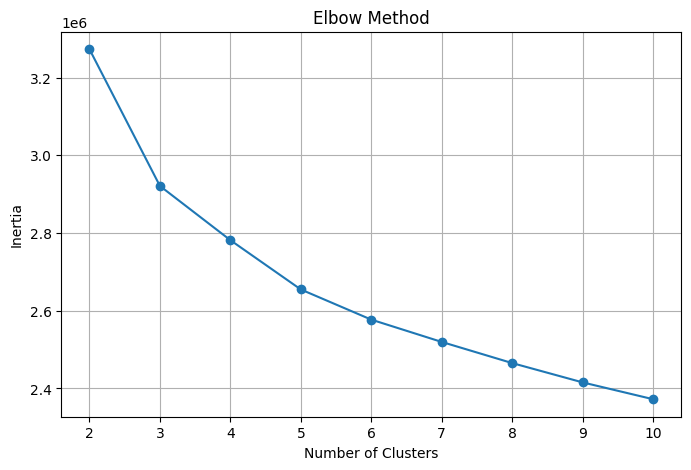

In [261]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [262]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    print(f"K={k}  Silhouette_Score={score:.4f}")

K=2  Silhouette_Score=0.4125
K=3  Silhouette_Score=0.3313
K=4  Silhouette_Score=0.1625
K=5  Silhouette_Score=0.1400
K=6  Silhouette_Score=0.1223
K=7  Silhouette_Score=0.0886
K=8  Silhouette_Score=0.0830
K=9  Silhouette_Score=0.0877
K=10  Silhouette_Score=0.0917


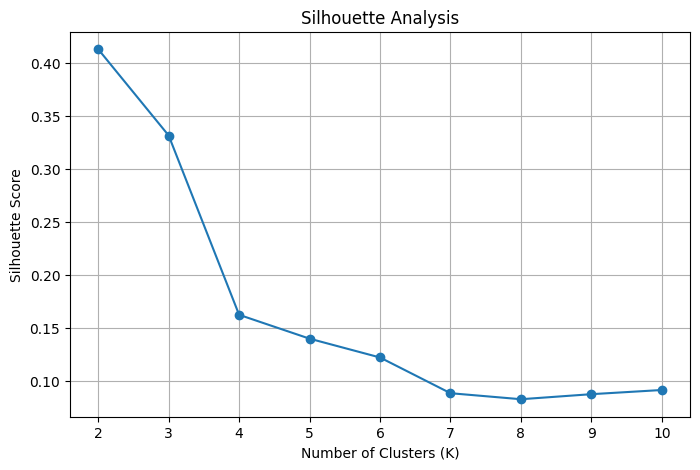

In [263]:
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.show()

#K-Means

In [264]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_pca)

results['KMeans'] = [
    silhouette_score(X_pca, kmeans_labels),
    calinski_harabasz_score(X_pca, kmeans_labels),
    davies_bouldin_score(X_pca, kmeans_labels)
]

print("KMeans Done")

KMeans Done


#K-Means Visualization

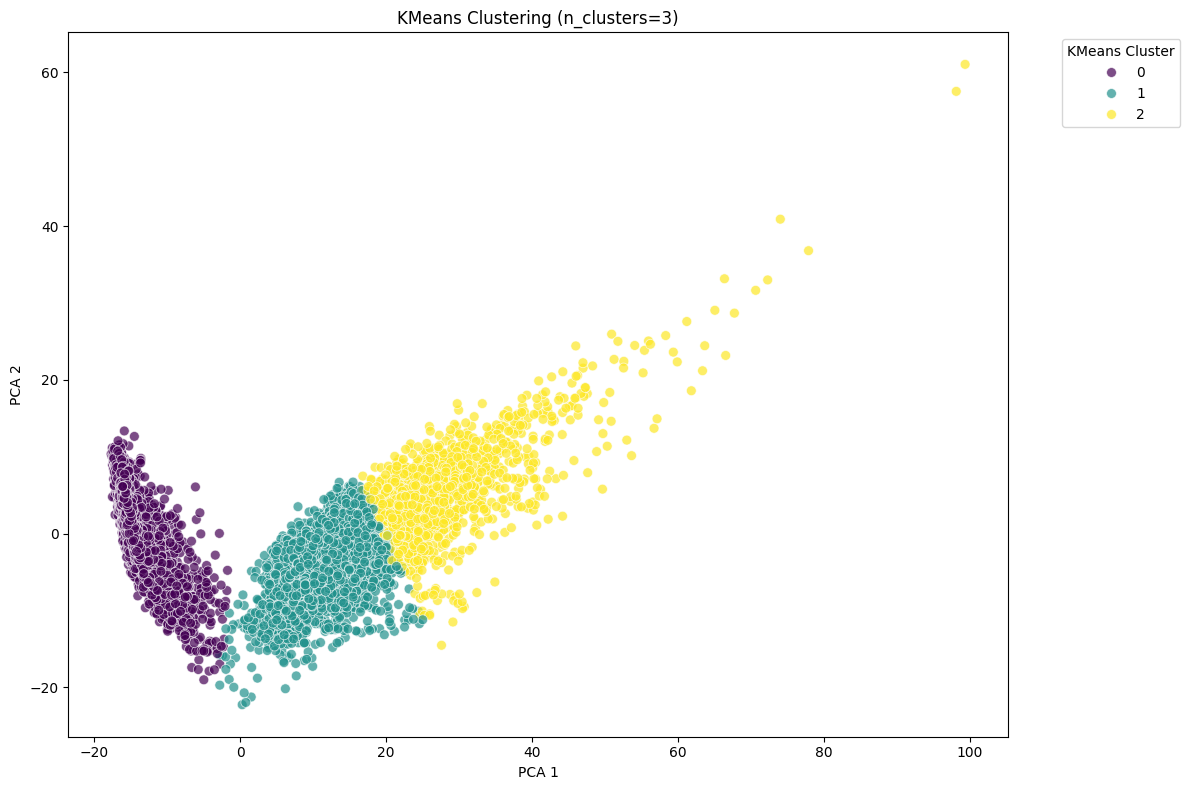

In [265]:
pca_df = pd.DataFrame(X_pca[:, :2], columns=['PCA 1', 'PCA 2'])
pca_df['KMeans_Label'] = kmeans_labels
pca_df['Activity'] = df['Activity'] # Keep Activity for reference if needed elsewhere

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA 1',
    y='PCA 2',
    hue='KMeans_Label', # Color by KMeans cluster labels
    data=pca_df,
    palette='viridis',
    s=50,
    alpha=0.7
)

plt.title("KMeans Clustering (n_clusters=3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='KMeans Cluster', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout()
plt.show()

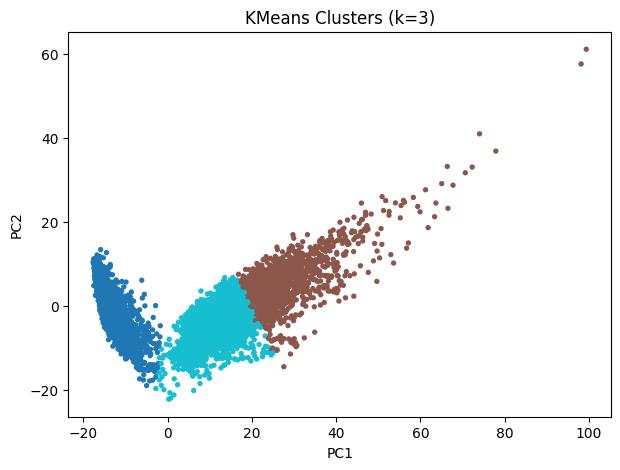

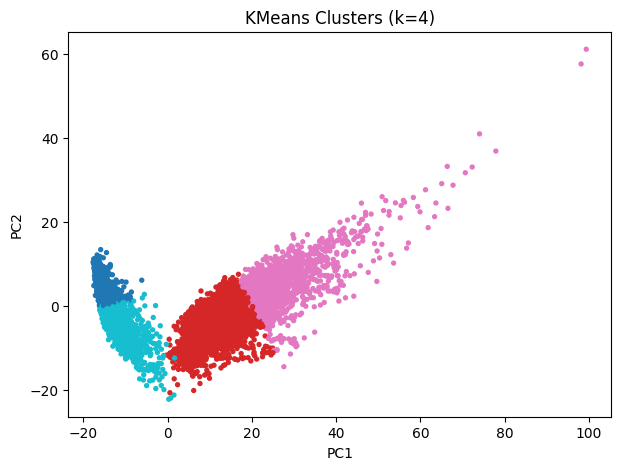

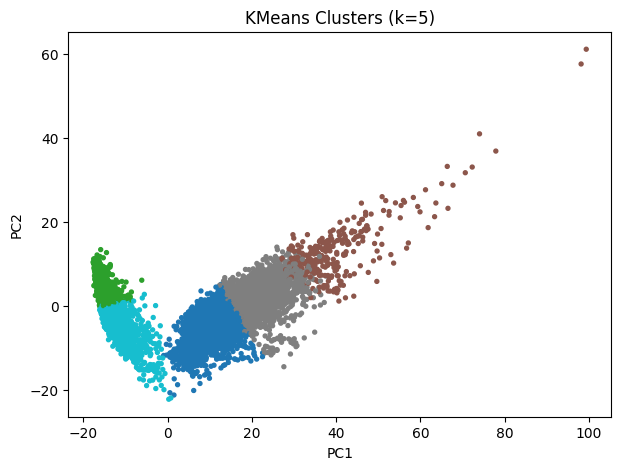

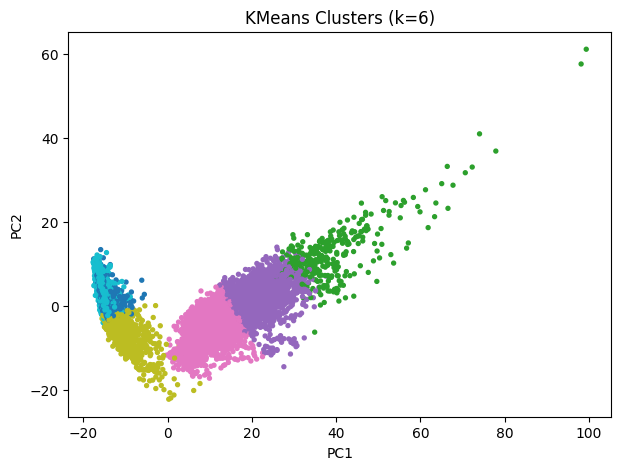

In [276]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_scaled)

for k in [3,4,5,6]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    plt.figure(figsize=(7,5))

    plt.scatter(
        X_vis[:,0],
        X_vis[:,1],
        c=labels,
        cmap='tab10',
        s=8
    )

    plt.title(f'KMeans Clusters (k={k})')

    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.show()

#Hierarchical Clustering

Because HAR contains 10,299 rows, don't use the full dataset.

Taking a sample as 3000 rows

In [266]:
sample_df = pd.DataFrame(X_pca).sample(
    n=3000,
    random_state=42
)

sample_data = sample_df.values

#Dendrogram

In [267]:
from sklearn.cluster import AgglomerativeClustering

# Assuming 3 clusters based on previous analysis or domain knowledge for hierarchical clustering
agg_clustering = AgglomerativeClustering(
    n_clusters=3
)

# Fit and predict on the sampled data for hierarchical clustering
hierarchical_labels = agg_clustering.fit_predict(sample_data)

# Calculate metrics and add to results
results['Hierarchical'] = [
    silhouette_score(sample_data, hierarchical_labels),
    calinski_harabasz_score(sample_data, hierarchical_labels),
    davies_bouldin_score(sample_data, hierarchical_labels)
]

print("Hierarchical Clustering Done")

Hierarchical Clustering Done


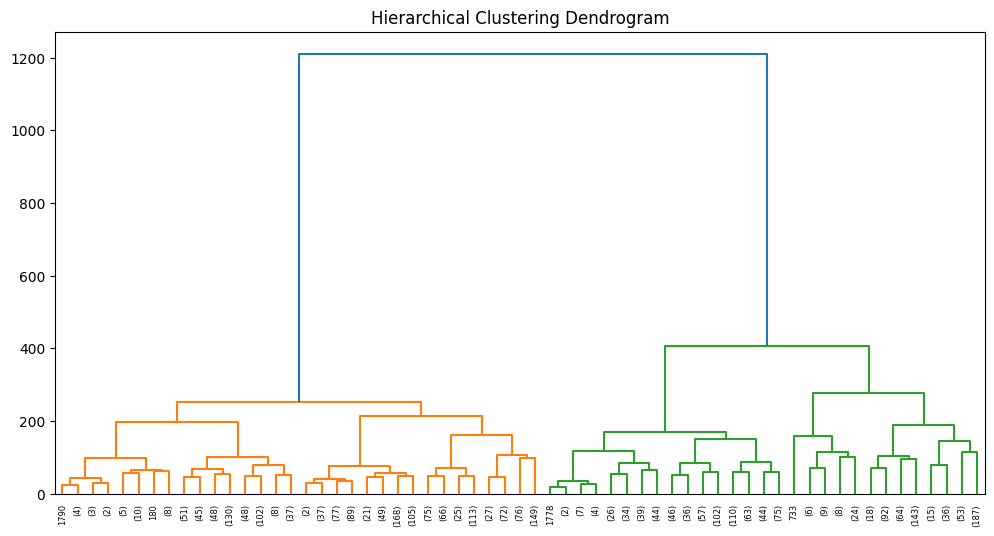

In [268]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(
    sample_data,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.show()

#Gaussian Mixture Model (GMM)

In [269]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_pca)

results['GMM'] = [
    silhouette_score(X_pca, gmm_labels),
    calinski_harabasz_score(X_pca, gmm_labels),
    davies_bouldin_score(X_pca, gmm_labels)
]

print("GMM Done")

GMM Done


#GMM Visualization

In [ ]:
pca_gmm_df = pd.DataFrame(X_pca[:, :2], columns=['PCA 1', 'PCA 2'])
pca_gmm_df['GMM_Label'] = gmm_labels
pca_gmm_df['Activity'] = df['Activity'] # Keep Activity for reference if needed elsewhere

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA 1',
    y='PCA 2',
    hue='GMM_Label', # Color by GMM cluster labels
    data=pca_gmm_df,
    palette='rainbow',
    s=50,
    alpha=0.7
)

plt.title("GMM Clustering (n_components=3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='GMM Cluster', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout()
plt.show()

#DBSCAN

In [270]:
dbscan = DBSCAN(
    eps=10,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_pca)

# Only add DBSCAN results if it finds more than one cluster (excluding noise label -1)
# This is crucial because metrics like silhouette_score are undefined for a single cluster or only noise.
if len(set(dbscan_labels)) > 1:

    results['DBSCAN'] = [
        silhouette_score(X_pca, dbscan_labels),
        calinski_harabasz_score(X_pca, dbscan_labels),
        davies_bouldin_score(X_pca, dbscan_labels)
    ]
else:
    print("DBSCAN did not form more than one cluster with current parameters. Adjust eps and min_samples if needed.")

print("DBSCAN Done")

DBSCAN Done


#DBSCAN Visualization

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

DBSCAN is currently finding only one cluster, which is why it is not appearing meaningfully in your clustering comparison.

#Final Comparison Table

In [ ]:
comparison = pd.DataFrame(
    results,
    index=[
        'Silhouette Score',
        'Calinski-Harabasz',
        'Davies-Bouldin'
    ]
).T

comparison

#Ranking Algorithms

In [271]:
comparison['Rank'] = (
    comparison['Silhouette Score'].rank(ascending=False)
    +
    comparison['Calinski-Harabasz'].rank(ascending=False)
    +
    comparison['Davies-Bouldin'].rank(ascending=True)
)

comparison = comparison.sort_values('Rank')

comparison

,Silhouette Score,Calinski-Harabasz,Davies-Bouldin,Rank
KMeans,0.331282,5580.548849,1.688943,3.0
Hierarchical,0.293203,1556.113604,1.842923,7.0
GMM,0.221040,4671.461953,2.151083,8.0
DBSCAN,-0.187191,106.057715,2.530687,12.0


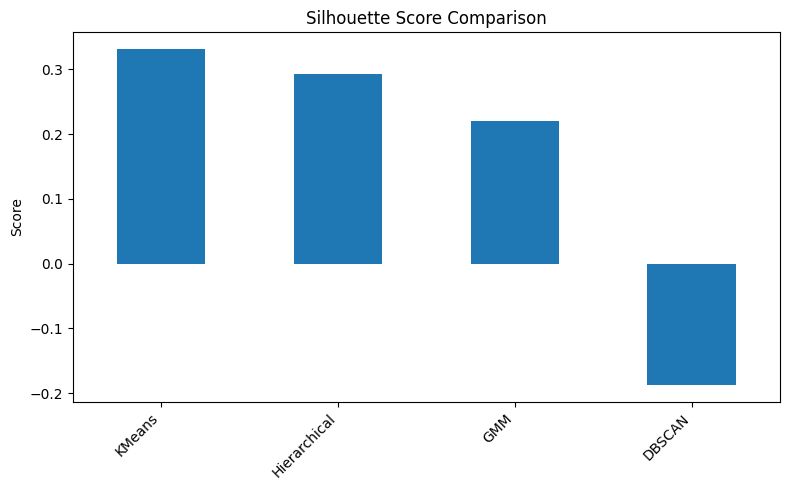

In [272]:
import matplotlib.pyplot as plt

comparison.plot(
    y="Silhouette Score",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Silhouette Score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### Score Conditions Explained:

*   **Silhouette Score:** A higher score (closer to 1) indicates better-defined and well-separated clusters.
*   **Calinski-Harabasz Index:** A higher score suggests more compact and well-separated clusters.
*   **Davies-Bouldin Index:** A lower score (closer to 0) indicates better clustering, implying good separation between clusters.

## Visualization of Algorithm Rankings

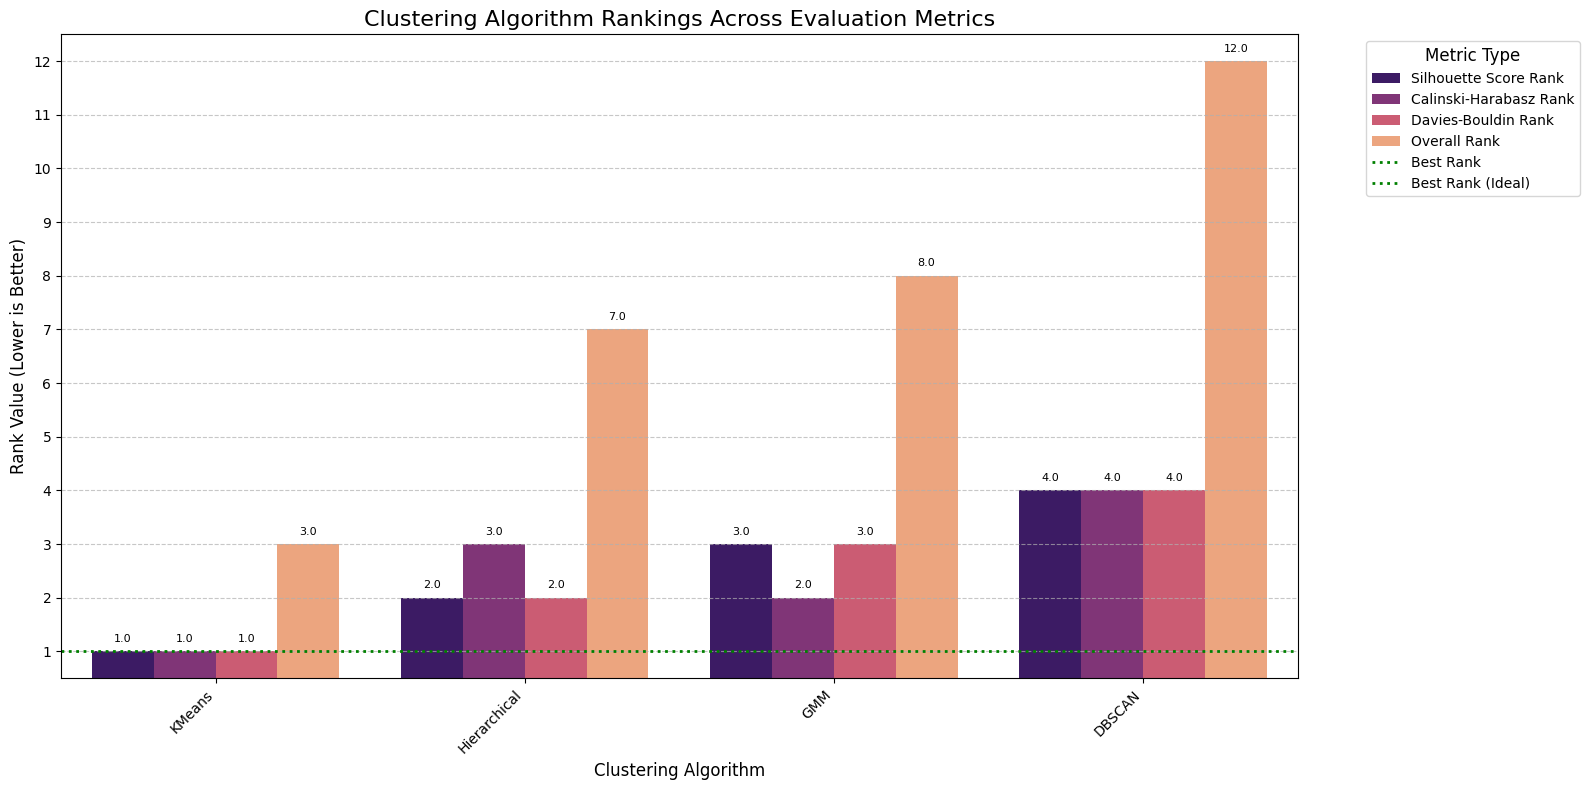

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame with ranks for each metric
rank_df = pd.DataFrame()
rank_df['Silhouette Score Rank'] = comparison['Silhouette Score'].rank(ascending=False)
rank_df['Calinski-Harabasz Rank'] = comparison['Calinski-Harabasz'].rank(ascending=False)
rank_df['Davies-Bouldin Rank'] = comparison['Davies-Bouldin'].rank(ascending=True) # Lower is better
rank_df['Overall Rank'] = comparison['Rank']

# Prepare the DataFrame for plotting (melt it)
rank_melted = rank_df.reset_index().melt(
    id_vars='index',
    var_name='Metric',
    value_name='Rank Value'
)
rank_melted = rank_melted.rename(columns={'index': 'Algorithm'})

plt.figure(figsize=(16, 8))
ax = sns.barplot(
    x='Algorithm',
    y='Rank Value',
    hue='Metric',
    data=rank_melted,
    palette='magma' # Changed palette for potentially better visual contrast
)

plt.title('Clustering Algorithm Rankings Across Evaluation Metrics', fontsize=16)
plt.xlabel('Clustering Algorithm', fontsize=12)
plt.ylabel('Rank Value (Lower is Better)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(range(1, int(rank_melted['Rank Value'].max()) + 2), fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add horizontal line at rank 1 to highlight the best rank
plt.axhline(y=1, color='green', linestyle=':', linewidth=2, label='Best Rank')

# Get current handles and labels from the barplot
handles, labels = ax.get_legend_handles_labels()

# Add the handle and label for the horizontal line
line = ax.lines[-1] # Get the last line added (which is our axhline)
handles.append(line)
labels.append('Best Rank (Ideal)') # Custom label for the line

# Update the legend
plt.legend(handles=handles, labels=labels, title='Metric Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=8,
                color='black')

plt.ylim(0.5, rank_melted['Rank Value'].max() + 0.5)
plt.tight_layout()
plt.show()

#Best Algorithm

In [274]:
best_algorithm = comparison.index[0]

print("Best Clustering Algorithm:")
print(best_algorithm)

Best Clustering Algorithm:
KMeans


#Conclusion

In [275]:
print(f"""
After comparing six clustering algorithms
on the Human Activity Recognition Dataset,
the best performing algorithm is:

{best_algorithm}

Evaluation Metrics Used:
1. Silhouette Score
2. Calinski-Harabasz Index
3. Davies-Bouldin Index

The algorithm achieved the most balanced
performance across all clustering metrics.
""")


After comparing six clustering algorithms
on the Human Activity Recognition Dataset,
the best performing algorithm is:

KMeans

Evaluation Metrics Used:
1. Silhouette Score
2. Calinski-Harabasz Index
3. Davies-Bouldin Index

The algorithm achieved the most balanced
performance across all clustering metrics.

